## Practical session 2: gradient descent and line-search

In today's session, we will implement the gradient descent algorithm and use it to solve problems of the form
$$
\min_{x \in \mathbb{R}^d} f(x).
$$
The gradient descent algorithm is a first-order algorithm, meaning that it only requires a first-order oracle of $f$. The performance of the gradient descent algorithm depends on only one parameter, called the step size. This step size can be fixed in advance if we have some information about the regularity of $f$, but it can also be adapted along the iterations if not enough information are available. In this practical session, you will implement the gradient descent algorithm with fixed step size as well as some strategies to iteratively adapt the step sizes.

### Gradient descent with fixed step size

Starting from an initial point $x_0 \in \mathbb{R}^d$, the gradient descent algorithm with fixed step size $\tau > 0$ generates a sequence $\{x_k\}$ such that for any $k \in \mathbb{N}$,
$$
x_{k+1} = x_k - \tau \nabla f(x_k).
$$
The stopping criterion for the gradient descent algorithm will generally be an approximate first-order stationarity condition of the form $\| \nabla f(x)\| \leq \epsilon$ for some small $\epsilon > 0$. A maximum number of iterations can also be enforced.

> Complete the function `GD` in the file `algorithms.py`.

In [1]:
from utils import *
from algorithms import *

%load_ext autoreload
%autoreload 2

You will now test the gradient descent algorithm on the objective function $f_1$.

In [2]:
import problem1 as pb1

> Plot the trajectory of the iterates generated by the gradient descent algorithm implemented in the function `GD` as well as the objective function and gradient norm values achieved by the iterates using the functions `level_points_plot` and `plot_obj_normGrad` from the file `utils.py`. Use $x_0 = (4,4)$ with a precision parameter $\texttt{prec}=10^{-5}$ and a maximum number of iteration $\texttt{iterMax} = 10^3$. Try the values $\tau \in \{0.1, 0.3, 0.5\}$.

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 139 iterations -- 0.001372s -- final value: 0.000000 -- final gradient norm: 0.000193 




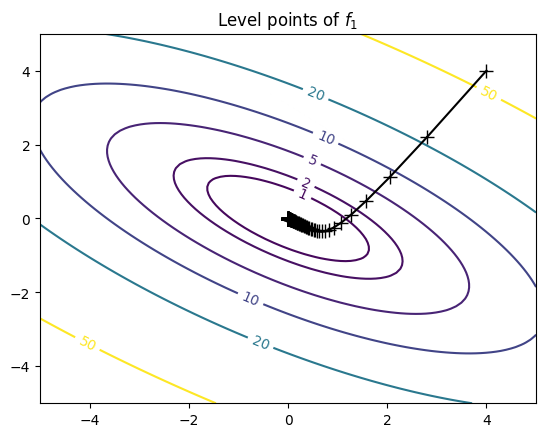

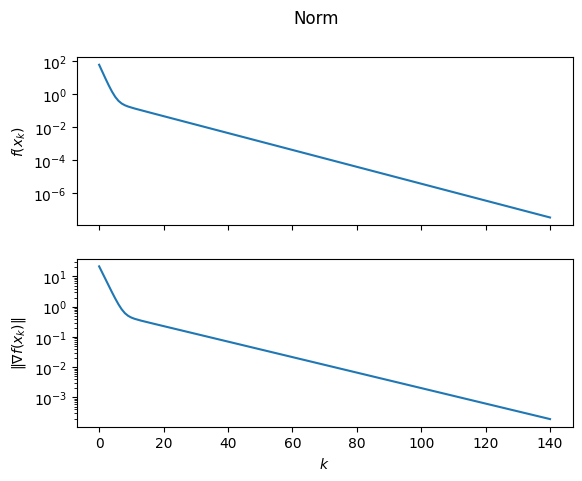

In [3]:
x_init = np.array([4,4])
prec = 1e-5
tau = 0.1
iterMax = 1000
x_final,x_tab = GD(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 44 iterations -- 0.000443s -- final value: 0.000000 -- final gradient norm: 0.000153 




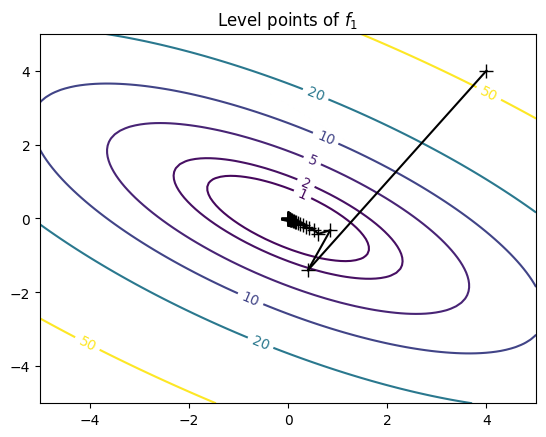

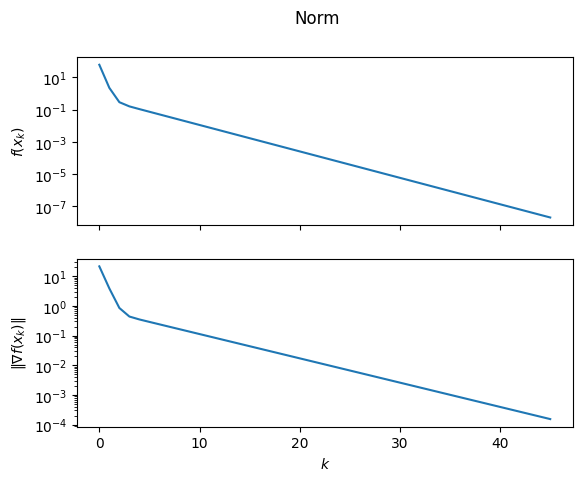

In [4]:
x_init = np.array([4,4])
prec = 1e-5
tau = 0.3
iterMax = 1000
x_final,x_tab = GD(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 310 iterations -- 0.002057s -- final value: 0.000000 -- final gradient norm: 0.000207 




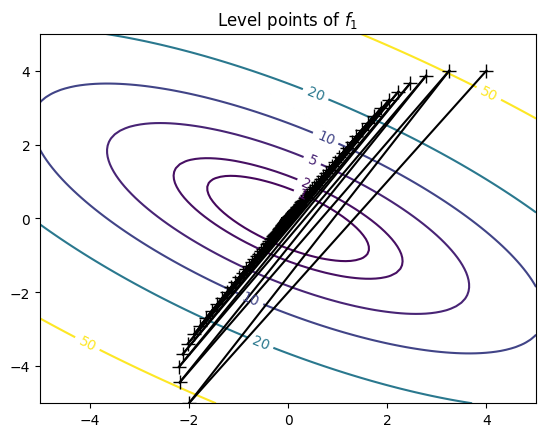

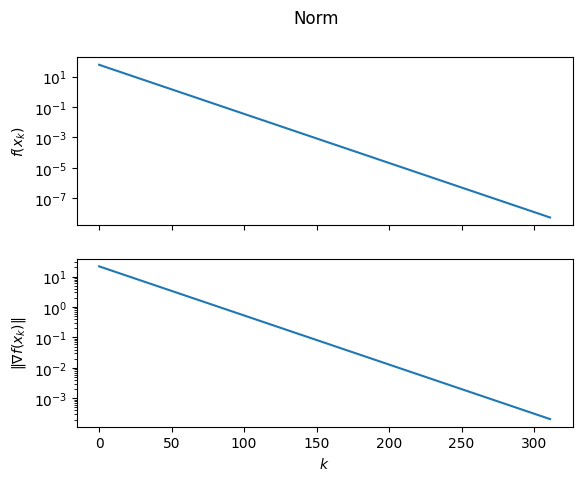

In [5]:
x_init = np.array([4,4])
prec = 1e-5
tau = 0.5
iterMax = 1000
x_final,x_tab = GD(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

> What is the "best" choice of step size among the three step sizes you tried?

> What happens if you try to larger values of $\tau$ (e.g., $\tau = 0.51$)?

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 0.005210s -- final value: 15842.421466 -- final gradient norm: 352.743524 




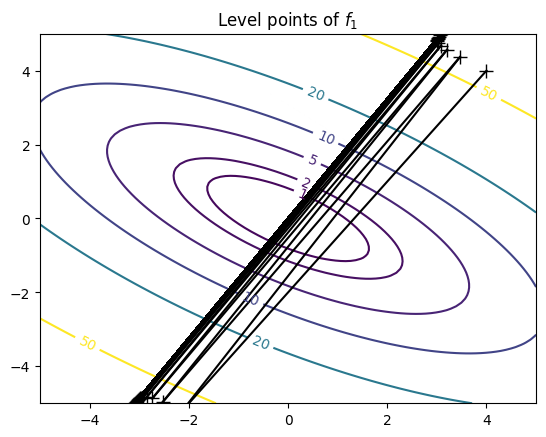

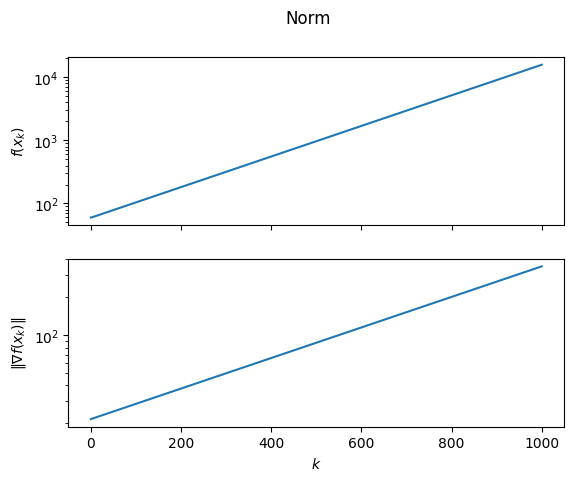

In [6]:
x_init = np.array([4,4])
prec = 1e-5
tau = 0.51
iterMax = 1000
x_final,x_tab = GD(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

### Line-search methods

As we saw in the previous example, gradient descent with fixed step size is very easy to implement and can convergence very fast on "easy" problems if the step size is well chosen. You will see in the lectures that if $\nabla f$ is $L$-Lipschitz, choosing $\tau \leq 1/L$ ensures that the iterates $\{ x_k \}$ generated by GD yield a non-increasing sequence $\{ f(x_k) \}$ and that $\nabla f(x_k) \rightarrow 0$ (these results can be strengthened under additional hypotheses on $f$). 

An alternative to knowing $L$ is to adapt the step size at every iteration. In this context, we will introduce line-search methods, which allow to achieve this goal. 

How do line-search methods work? At iteration $k \in \mathbb{N}$, the GD algorithm updates the iterate $x_k$ using the update
$$
x_{k+1} = x_k - \tau \nabla f(x_k)
$$
for some $\tau > 0$. Then, a natural idea is to consider the function $\phi_k : (0,\infty) \rightarrow \mathbb{R}$ defined for any $\tau > 0$ by
$$
\phi_k(\tau) = f(x_k - \tau \nabla f(x_k))
$$
and minimize it. Notice that $\phi_k(0) = f(x_k)$. Minimizing $\phi_k$ is generally too costly, so line-search methods only aim at finding $\tau > 0$ such that
$$
f(x_k - \tau \nabla f(x_k)) \leq f(x_k) - c \tau \| \nabla f(x_k) \|^2
$$
is satisfied for some value $c \in (0,1)$. This condition is called the Armijo condition and requires the line-search to achieve a sufficient decrease in the function $f$ (controlled by the constant $c$) at every iteration.

The backtracking line-search (also called Armijo line-search) is a straightforward line-search method that allows to find step sizes $\tau$ satisfying the Armijo condition. Backtracking works as follows:
- choose parameters $\tau_0 > 0$, $c \in (0,1)$, and $\rho \in (0,1)$ and set $\tau \leftarrow \tau_0$.
- while $f(x_k - \tau \nabla f(x_k)) > f(x_k) + c \tau \| \nabla f(x_k) \|^2$, update $\tau \leftarrow \rho \tau$.
- once the loop stops, use the final value of $\tau$ as the step size in the gradient descent algorithm.

> Implement the gradient descent algorithm with backtracking line-search in the `algorithms.py` file.

> Run the gradient descent algorithm with backtracking line-search on the function $f_1$ with $\rho = 0.5$, $c=0.01$, and $\tau_0 \in \{0.1, 1.0, 10.0\}$. What do you observe and how do you interpret these results?

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 139 iterations -- 0.002046s -- final value: 0.000000 -- final gradient norm: 0.000193 




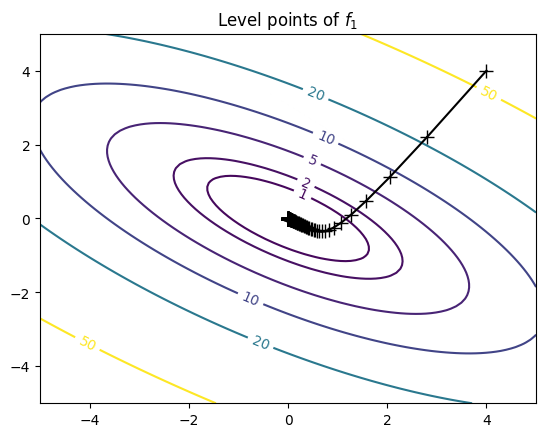

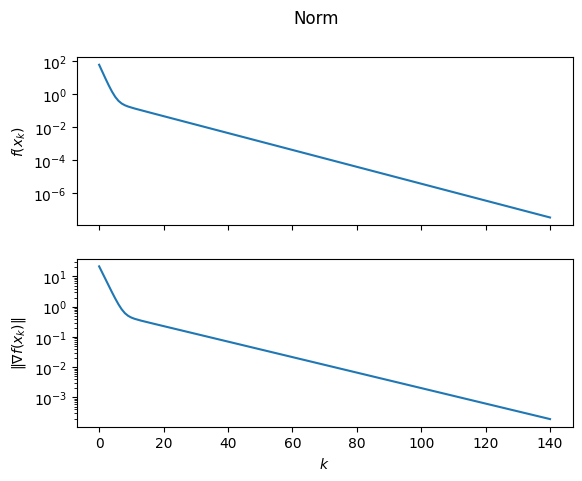

In [7]:
x_init = np.array([4,4])
prec = 1e-5
tau = 0.1
iterMax = 1000
rho = .5
c = .01
x_final,x_tab = GD_ls(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec,rho, c)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 310 iterations -- 0.005702s -- final value: 0.000000 -- final gradient norm: 0.000207 




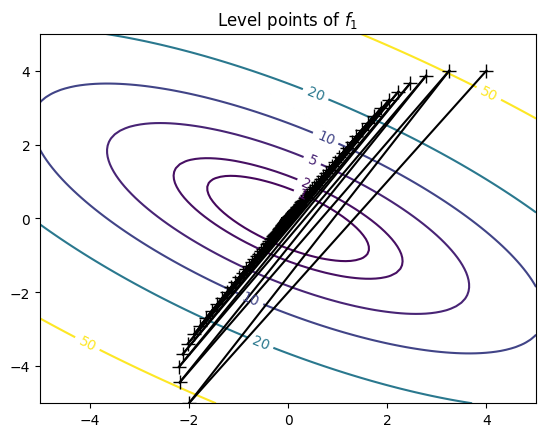

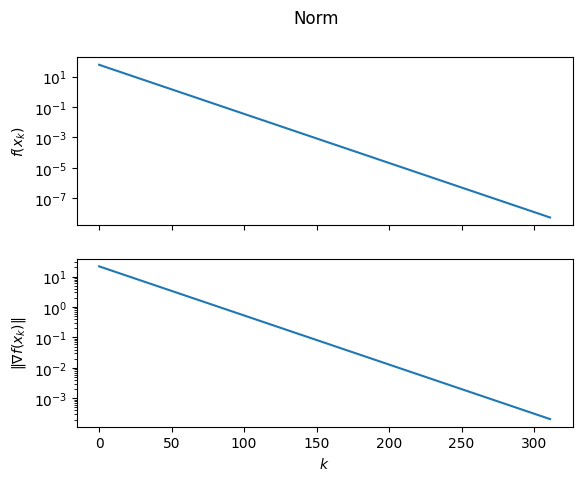

In [8]:
x_init = np.array([4,4])
prec = 1e-5
tau = 1.
iterMax = 1000
rho = .5
c = .01
x_final,x_tab = GD_ls(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec,rho, c)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 20 iterations -- 0.001167s -- final value: 0.000000 -- final gradient norm: 0.000116 




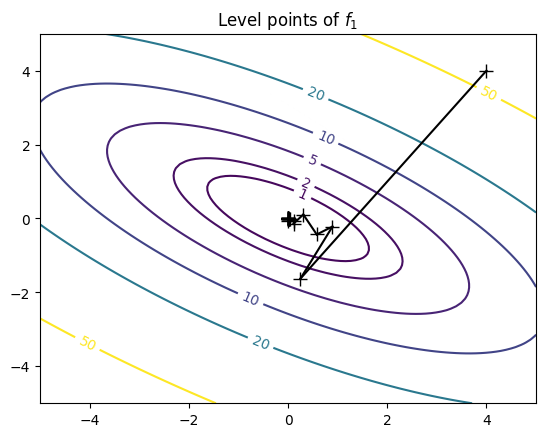

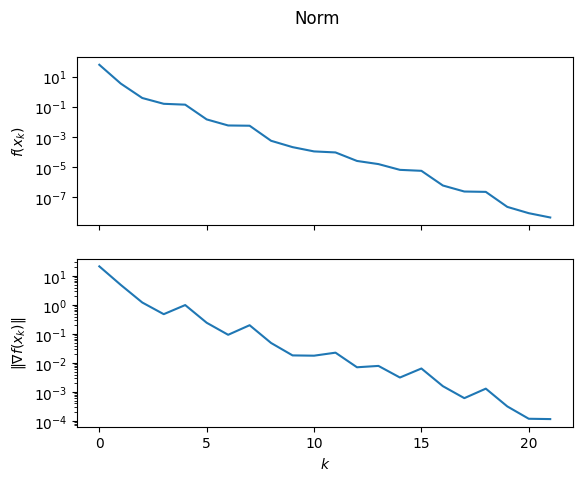

In [9]:
x_init = np.array([4,4])
prec = 1e-5
tau = 10.
iterMax = 1000
rho = .5
c = .01
x_final,x_tab = GD_ls(pb1.f,pb1.grad_f,x_init,tau,iterMax,prec,rho, c)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

### To go further: Exact line-search for quadratic problems

In general, minimizing the function $\phi_k : \tau \longmapsto f(x_k - \tau \nabla f(x_k))$ is not worth the effort, so line-search methods only aim at finding a step size $\tau$ that satisfies a sufficient decrease condition. However, if $f$ is quadratic, that is
$$
f(x) = \frac{1}{2} x^\top A x + b^\top x + c
$$
with $A \succcurlyeq 0$ and symmetric, then the minimizer of $\phi_k$ can be written in closed-form. 

> Solve $\phi_k^\prime(\tau) = 0$ in $\tau$ (use that $\nabla f(x) = Ax + b$ at some point). The solution is the optimal step size for the iteration $k$.

> Implement the gradient descent algorithm with exact line-search for quadratic functions and run it on $f_1$ (you can use that $A$ is the Hessian of $A$).

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 5 iterations -- 0.000534s -- final value: 0.000000 -- final gradient norm: 0.000004 




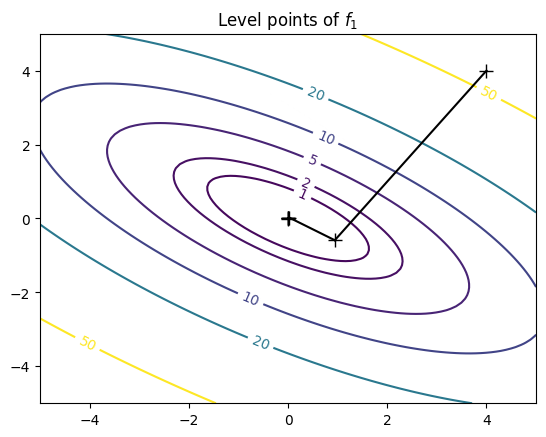

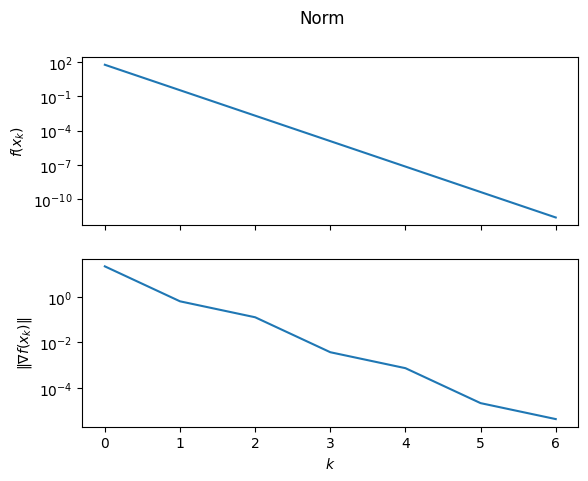

In [12]:
### TO C

x_init = np.array([4,4])
prec = 1e-5
iterMax = 1000
x_final,x_tab = GD_sec_order_exact(pb1.f,pb1.grad_f,pb1.hessian_f,x_init,iterMax, prec)

level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,r"Level points of $f_1$")
plot_obj_normGrad(x_tab, pb1.f,pb1.grad_f, "Norm")

### To go further: A more challenging quadratic problem

The objective function $f_1$ is a quadratic function which is relatively simple to minimize: its Hessian matrix has a low condition number (ratio of the largest and smallest eigenvalues, this quantity controls the "elongation" of the level sets) and the search space is low-dimensional. You are now going to consider the objective function $f_3$, which is a quadratic function in dimension $d=10^3$ whose Hessian has a condition number $\kappa = 10^6$ (note that these numbers are still small compared to some large-scale optimization problems seen in some applications such as machine learning, image processing, or meteorology, to name a few).

In [13]:
import problem3 as pb3

> Try running the gradient descent algorithm with fixed step size $\tau \in \{ 10^{-7}, 10^{-6}, 10^{-5} \}$, the gradient descent algorithm with backtracking line search, and the gradient descent algorithm with perfect line search to minimize $f_3$.

In [ ]:
### TO COMPLETE
x_init = np.array([0,0,0])
prec = 1e-5
tau = 1e-7
iterMax = 1000
x_final,x_tab = GD(pb3.f,pb3.grad_f,x_init,tau,iterMax,prec)

level_points_plot(pb3.f,x_tab,pb3.lb,pb3.ub,pb3.nb_points,pb3.levels,r"Level points of $f_3$")
plot_obj_normGrad(x_tab, pb3.f,pb3.grad_f, "Norm")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 1000)

In [ ]:
### TO COMPLETE

In [ ]:
### TO COMPLETE

In [ ]:
### TO COMPLETE

In [ ]:
### TO COMPLETE

### To go further: Minimizing the Rosenbrock function

Only quadratic objective functions have been considered so far. Let us now try to use gradient descent algorithms to minimize the Rosenbrock function $f_2$.

In [ ]:
import problem2 as pb2

> Find a step size $\tau > 0$ such that the gradient descent algorithm with fixed step size generates a decreasing sequence $\{ f(x_k)\}$ of function values when initialized at $(0,0)$.

In [ ]:
### TO COMPLETE

> Does this step size still allows to achieve decrease when starting from outside of the "valley" of $f_2$, for instance if $x_0 = (-4,-4)$?

In [ ]:
### TO COMPLETE

> Try to see if backtracking can help in minimizing the Rosenbrock function.

In [ ]:
### TO COMPLETE